In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

In [146]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Exploring games data

In [147]:
clean_games_fp = Path(config['games_folder'] + config['games_clean_fp'])

games_df = pd.read_json(clean_games_fp, orient='records')
games_df['updated_at'] = pd.to_datetime(games_df['updated_at'], errors='coerce')
games_df['first_release_date'] = pd.to_datetime(games_df['first_release_date'], errors='coerce')

games_df.head()

,name,rating,updated_at,first_release_date,id,game_modes_Battle Royale,game_modes_Co-operative,game_modes_Massively Multiplayer Online (MMO),game_modes_Multiplayer,game_modes_Single player,...,platforms_WonderSwan Color,platforms_Xbox,platforms_Xbox 360,platforms_Xbox One,platforms_Xbox Series X|S,platforms_ZX Spectrum,platforms_Zeebo,platforms_e-Reader / Card-e Reader,platforms_iOS,platforms_visionOS
0,Apes Warfare,-1.000000,2026-05-01 16:00:12,2026-04-29,374123,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,Spellfarers,-1.000000,2026-05-01 15:53:03,2026-04-29,308580,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,Warframe,74.773808,2026-05-01 15:49:54,2013-03-25,2903,0,1,0,1,1,...,0,0,0,1,1,0,0,0,1,0
3,The Elder Scrolls Online,71.794992,2026-05-01 15:49:43,2014-04-04,1081,0,1,1,1,1,...,0,0,0,1,1,0,0,0,0,0
4,Call of Duty: Warzone,66.793295,2026-05-01 15:49:41,2022-11-16,217815,1,1,0,1,1,...,0,0,0,1,1,0,0,0,0,0


In [148]:
games_df.head()

,name,rating,updated_at,first_release_date,id,game_modes_Battle Royale,game_modes_Co-operative,game_modes_Massively Multiplayer Online (MMO),game_modes_Multiplayer,game_modes_Single player,...,platforms_WonderSwan Color,platforms_Xbox,platforms_Xbox 360,platforms_Xbox One,platforms_Xbox Series X|S,platforms_ZX Spectrum,platforms_Zeebo,platforms_e-Reader / Card-e Reader,platforms_iOS,platforms_visionOS
0,Apes Warfare,-1.000000,2026-05-01 16:00:12,2026-04-29,374123,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,Spellfarers,-1.000000,2026-05-01 15:53:03,2026-04-29,308580,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,Warframe,74.773808,2026-05-01 15:49:54,2013-03-25,2903,0,1,0,1,1,...,0,0,0,1,1,0,0,0,1,0
3,The Elder Scrolls Online,71.794992,2026-05-01 15:49:43,2014-04-04,1081,0,1,1,1,1,...,0,0,0,1,1,0,0,0,0,0
4,Call of Duty: Warzone,66.793295,2026-05-01 15:49:41,2022-11-16,217815,1,1,0,1,1,...,0,0,0,1,1,0,0,0,0,0


In [149]:
#Checking to make sure the id uniquely identifies each row
print("No duplicate IDS") if len(games_df['id'].unique()) == len(games_df) else print("Duplicate IDs found")

No duplicate IDS


In [150]:
#Checking to see if duplicate game names exist
print("No duplicate game names") if len(games_df['name'].unique()) == len(games_df) else print("Duplicate game names found")

Duplicate game names found


In [151]:
#Get all rows with duplicate game names
duplicate_names_df = games_df[games_df.duplicated(subset=['name'], keep=False)].sort_values('name')
duplicate_names_df.head(6)

,name,rating,updated_at,first_release_date,id,game_modes_Battle Royale,game_modes_Co-operative,game_modes_Massively Multiplayer Online (MMO),game_modes_Multiplayer,game_modes_Single player,...,platforms_WonderSwan Color,platforms_Xbox,platforms_Xbox 360,platforms_Xbox One,platforms_Xbox Series X|S,platforms_ZX Spectrum,platforms_Zeebo,platforms_e-Reader / Card-e Reader,platforms_iOS,platforms_visionOS
17029,10-Pin Bowling,-1.000000,2024-11-14 09:33:09,1984-12-31,153453,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
17030,10-Pin Bowling,-1.000000,2024-11-14 09:27:27,1999-08-01,92273,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
7366,15 Minutes,-1.000000,2026-04-09 19:38:22,2026-01-05,395433,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
12963,15 Minutes,-1.000000,2026-02-02 16:52:35,2025-10-23,355071,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5949,1942,61.392350,2026-04-18 08:37:59,1985-12-11,272544,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
6791,1942,67.742592,2026-04-13 08:03:19,1984-12-01,6075,0,1,0,1,1,...,0,0,0,0,0,1,0,0,0,0


In [152]:
#Find columns where duplicates differ (excluding name, rating, updated_at, id)
exclude_cols = {'name', 'rating', 'updated_at', 'id'}
cols_to_check = [col for col in duplicate_names_df.columns if col not in exclude_cols]

i = 0
for game_name in duplicate_names_df['name'].unique():
    game_group = duplicate_names_df[duplicate_names_df['name'] == game_name]
    differing_cols = []
    for col in cols_to_check:
        if len(game_group[col].unique()) > 1:
            differing_cols.append(col)
    if'first_release_date' not in differing_cols:  # Print every 10th game to avoid too much output
        #print(f"{game_name}: {differing_cols}")
        pass
    i+=1

There are many duplicates but they may functionally differ so we'll keep them for now

## Conflicts in game modes columns

There are several game mode columns that seem to imply multiplayer functionality (such as Co-operative or Massively Multiplayer Online), but we should check if they actually do inherently imply multiplayer compatibility. If not, we should make sure we understand what the column is referring to.

In [153]:
coop_without_multiplayer = games_df.groupby(['game_modes_Co-operative', 'game_modes_Multiplayer'])[['name', 'first_release_date']].agg(lambda x: x.sample(1))
coop_without_multiplayer

name  \
game_modes_Co-operative game_modes_Multiplayer                                
0                       0                       Powerpuff Girls: Power Surf   
                        1                                  Race Driver 2006   
1                       1                                          Tin Star   

                                               first_release_date  
game_modes_Co-operative game_modes_Multiplayer                     
0                       0                              2002-02-17  
                        1                              2018-12-08  
1                       1                              2022-05-17

For co-op, it seems like an error in entry; games with coop should have a 1 in the multiplayer column.

In [154]:
br_without_multiplayer = games_df.groupby(['game_modes_Battle Royale', 'game_modes_Multiplayer'])[['name', 'first_release_date']].agg(lambda x: x.sample(1))
br_without_multiplayer

name  \
game_modes_Battle Royale game_modes_Multiplayer                                            
0                        0                                       Valhalla Knights 3 Gold   
                         1                                           Dr. Mario Online Rx   
1                        0                       JoJo's Bizarre Adventure: Last Survivor   
                         1                                                     HypeSquad   

                                                first_release_date  
game_modes_Battle Royale game_modes_Multiplayer                     
0                        0                              2021-03-26  
                         1                              2007-03-21  
1                        0                              2020-09-01  
                         1                              2022-02-07

Same for MMO

# Exploring multiplayer modes data

In [155]:
clean_modes_fp = Path(config['multiplayer_modes_folder'] + config['multiplayer_modes_clean_fp'])

modes_df = pd.read_json(clean_modes_fp, orient='records')

print("Contains " + str(len(modes_df)) + " rows")
modes_df.head()

Contains 24033 rows


,id,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,platform,splitscreen
0,9953,92273,False,False,False,0,2,False,0,0,Game Boy Color,False
1,1832,7153,True,True,True,2,0,False,0,0,Xbox 360,False
2,7987,57887,False,False,True,2,2,False,0,0,Xbox One,False
3,7,46076,False,False,False,0,30,False,0,0,PC (Microsoft Windows),False
4,10207,31256,False,False,False,0,0,False,0,0,Web browser,False


In [156]:
modes_df.isna().mean().sort_values(ascending=False)

id                0.0
game              0.0
dropin            0.0
campaigncoop      0.0
offlinecoop       0.0
offlinecoopmax    0.0
offlinemax        0.0
onlinecoop        0.0
onlinecoopmax     0.0
onlinemax         0.0
platform          0.0
splitscreen       0.0
dtype: float64

-1 as a fill value works fine for all of these

In [157]:
def isunique(df, subset):
    return len(df[subset].unique()) == len(df)

print("No duplicate IDS") if isunique(modes_df, 'id') else print("Duplicate IDs found")
print("No duplicate game ids") if isunique(modes_df, 'game') else print("Duplicate game ids found")

No duplicate IDS
Duplicate game ids found


In [158]:
duplicate_game_ids_df = modes_df[modes_df.duplicated(subset=['game'], keep=False)].sort_values('game')
duplicate_game_ids_df = duplicate_game_ids_df.merge(games_df[['id', 'name']], left_on='game', right_on='id', how='left', suffixes=('_mode', '_game'))
duplicate_game_ids_df.head(10)

,id_mode,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,platform,splitscreen,id_game,name
0,11593,72,False,False,True,2,0,True,2,0,PC (Microsoft Windows),True,72.0,Portal 2
1,11594,72,False,False,True,2,0,True,2,0,Mac,True,72.0,Portal 2
2,11592,72,False,False,True,2,0,True,2,0,PlayStation 3,True,72.0,Portal 2
3,11591,72,False,False,True,2,0,True,2,0,Xbox 360,True,72.0,Portal 2
4,11595,72,False,False,True,2,0,True,2,0,Linux,True,72.0,Portal 2
5,1631,83,False,True,True,2,0,False,0,0,PlayStation 2,False,83.0,Baldur's Gate: Dark Alliance
6,17435,83,False,False,False,0,0,False,0,0,PC (Microsoft Windows),True,83.0,Baldur's Gate: Dark Alliance
7,11139,121,True,True,False,0,0,False,0,0,Linux,False,121.0,Minecraft: Java Edition
8,11138,121,True,True,False,0,0,False,0,0,Mac,False,121.0,Minecraft: Java Edition
9,11137,121,True,True,False,0,0,False,0,0,PC (Microsoft Windows),False,121.0,Minecraft: Java Edition


Duplicate IDS often seems to indicate multi-platform releases

In [159]:
full_df = modes_df.merge(games_df, left_on='game', right_on='id', how='left', suffixes=('', '_game'))
full_df.head()

,id,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,...,platforms_WonderSwan Color,platforms_Xbox,platforms_Xbox 360,platforms_Xbox One,platforms_Xbox Series X|S,platforms_ZX Spectrum,platforms_Zeebo,platforms_e-Reader / Card-e Reader,platforms_iOS,platforms_visionOS
0,9953,92273,False,False,False,0,2,False,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1832,7153,True,True,True,2,0,False,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,7987,57887,False,False,True,2,2,False,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,7,46076,False,False,False,0,30,False,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10207,31256,False,False,False,0,0,False,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Handling conflicting values across columns

In [160]:
columns = ['offlinecoop', 'offlinecoopmax', 'offlinemax']

def cap_at_1(x):
    return 1 if x >= 1 else x

for col in columns[1:]:
    full_df[col] = full_df[col].apply(cap_at_1)

full_df[columns[-1]].value_counts()

offlinemax
0    16592
1     7441
Name: count, dtype: int64

In [161]:
#Sample one row from each unique combination of columns
selected_cols = ['name', 'first_release_date', 'platform'] + [col for col in full_df.columns if 'game_modes' in col]
conflict_scenarios_df = full_df.groupby(columns)[selected_cols].count()#agg(lambda x: x.sample(1))

#conflict_scenarios_df = conflict_scenarios_df.drop(labels = [()])
conflict_scenarios_df

name  first_release_date  platform  \
offlinecoop offlinecoopmax offlinemax                                        
False       0              0           14971               14971     15007   
                           1            4745                4745      4748   
True        1              0            1583                1583      1585   
                           1            2692                2692      2693   

                                       game_modes_Battle Royale  \
offlinecoop offlinecoopmax offlinemax                             
False       0              0                              14971   
                           1                               4745   
True        1              0                               1583   
                           1                               2692   

                                       game_modes_Co-operative  \
offlinecoop offlinecoopmax offlinemax                            
False       0              0                             14971   
                           1                              4745   
True        1              0                              1583   
                           1                              2692   

                                       game_modes_Massively Multiplayer Online (MMO)  \
offlinecoop offlinecoopmax offlinemax                                                  
False       0              0                                                   14971   
                           1                                                    4745   
True        1              0                                                    1583   
                           1                                                    2692   

                                       game_modes_Multiplayer  \
offlinecoop offlinecoopmax offlinemax                           
False       0              0                            14971   
                           1                             4745   
True        1              0                             1583   
                           1                             2692   

                                       game_modes_Single player  \
offlinecoop offlinecoopmax offlinemax                             
False       0              0                              14971   
                           1                               4745   
True        1              0                               1583   
                           1                               2692   

                                       game_modes_Split screen  
offlinecoop offlinecoopmax offlinemax                           
False       0              0                             14971  
                           1                              4745  
True        1              0                              1583  
                           1                              2692

After inspecting some examples of each combination of the `offlinecoop`, `offlinecoopmax`, and `offlinemax` columns; the meanings can be interpreted as follows:

| offlinecoop | offlinecoopmax | offlinemax | Meaning |
| -------- | ------- | -------- | -------- |
| True | -1 | 1 | Misinput; trust data from games endpoint |
| True | 0 | 1 | Used the other column, fill coop max with max |
| True | 1 | -1 | Offline coop but no PVP |
| True | 1 | 0 | Offline coop but no PVP |
| True | 1 | 1 | Offline coop and PVP |
| False | -1 | -1 | No offline play |
| False | -1 | 0 | No offline play |
| False | -1 | 1 | Offline PVP but no coop |
| False | 0 | -1 | No offline play |
| False | 0 | 0 | No offline play |
| False | 0 | 1 | Inconsistent, assume no offline play |
| False | 1 | -1 | Inconsistent; assume no offline play|
| False | 1 | 0 | Inconsistent; assume no offline play|


There are only 5 error cases:

1. offlinecoop = True, offlinecoopmax \< 0, and offlinemax \> 0 

2. offlinecoop = True, offlinecoopmax = 0, and offlinemax \> 0 

3. offlinecoop = False, offlinecoopmax = 0, and offlinemax \> 0 

4. offlinecoop = False, offlinecoopmax \> 0, and offlinemax \< 0 

5. offlinecoop = False, offlinecoopmax \> 0, and offlinemax = 0 


In [162]:
from data_cleaning_functions import get_replacement_function

offline = {'coop_column' : 'offlinecoop',
           'coop_max_column' : 'offlinecoopmax',
           'max_column' : 'offlinemax'}
online = {'coop_column' : 'onlinecoop',
           'coop_max_column' : 'onlinecoopmax',
           'max_column' : 'onlinemax'}

fixed_df = full_df.apply(get_replacement_function(**offline), axis = 1)
fixed_df = fixed_df.apply(get_replacement_function(**online), axis = 1)

conflict_scenarios_df = fixed_df.groupby(columns)[selected_cols].agg(lambda x: x.sample(1))

#conflict_scenarios_df = conflict_scenarios_df.drop(labels = [()])
conflict_scenarios_df

name  \
offlinecoop offlinecoopmax offlinemax                                            
False       0              0                                         Runeverse   
True        1              0                                    Gears of War 3   
                           1           LEGO Harry Potter Collection: Years 1-4   

                                      first_release_date         platform  \
offlinecoop offlinecoopmax offlinemax                                       
False       0              0                  2021-11-19      Nintendo DS   
True        1              0                  2016-10-27         Xbox 360   
                           1                  2010-12-20  Nintendo Switch   

                                       game_modes_Battle Royale  \
offlinecoop offlinecoopmax offlinemax                             
False       0              0                                0.0   
True        1              0                                0.0   
                           1                                0.0   

                                       game_modes_Co-operative  \
offlinecoop offlinecoopmax offlinemax                            
False       0              0                               0.0   
True        1              0                               1.0   
                           1                               1.0   

                                       game_modes_Massively Multiplayer Online (MMO)  \
offlinecoop offlinecoopmax offlinemax                                                  
False       0              0                                                     0.0   
True        1              0                                                     0.0   
                           1                                                     0.0   

                                       game_modes_Multiplayer  \
offlinecoop offlinecoopmax offlinemax                           
False       0              0                              1.0   
True        1              0                              1.0   
                           1                              1.0   

                                       game_modes_Single player  \
offlinecoop offlinecoopmax offlinemax                             
False       0              0                                1.0   
True        1              0                                1.0   
                           1                                1.0   

                                       game_modes_Split screen  
offlinecoop offlinecoopmax offlinemax                           
False       0              0                               0.0  
True        1              0                               0.0  
                           1                               1.0

## Handling Outliers

### Offline multiplayer

In [188]:
offlinemax_column = modes_df['offlinemax'].sort_values(ascending = False)
outliers = offlinemax_column.iloc[:20]

In [189]:
max_games = modes_df.loc[outliers.index]
max_games

,id,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,platform,splitscreen
23729,40716,397932,False,True,True,100,100,True,100,100,PC (Microsoft Windows),False
15450,33197,336303,True,False,False,0,100,False,0,0,Web browser,False
14469,25815,281324,False,False,True,100,100,True,100,100,PC (Microsoft Windows),False
4581,11018,135226,True,False,True,100,100,False,0,2,PC (Microsoft Windows),True
1775,11658,138335,True,False,True,100,100,True,100,100,Legacy Mobile Device,False
4986,11958,130747,True,False,True,99,99,False,0,0,Linux,True
13645,24662,242408,True,True,True,99,99,True,99,99,Linux,False
12887,23440,242408,True,True,True,99,99,True,99,99,PC (Microsoft Windows),False
4987,11957,130747,True,False,True,99,99,False,0,0,PC (Microsoft Windows),True
21915,37110,297097,True,True,True,12,64,True,12,64,PC (Microsoft Windows),False


In [190]:
max_games.merge(games_df, how = 'left', left_on = 'game', right_on = 'id')[['name', 'platform', 'offlinemax']]

,name,platform,offlinemax
0,Kobayashi Clash of Conquest,PC (Microsoft Windows),100
1,Redactionary,Web browser,100
2,Return: Unknown,PC (Microsoft Windows),100
3,A Buttload of Free Games,PC (Microsoft Windows),100
4,ScarFall: The Royale Combat,Legacy Mobile Device,100
5,Progress Bar Simulator,Linux,99
6,Counter-Strike 2,Linux,99
7,Counter-Strike 2,PC (Microsoft Windows),99
8,Progress Bar Simulator,PC (Microsoft Windows),99
9,Comando Rio,PC (Microsoft Windows),64


In [191]:
offlinemax_column.value_counts()

offlinemax
0      16592
2       3951
4       2071
1        679
8        299
6         94
3         92
10        54
12        52
5         40
16        39
32        15
20         9
100        5
50         5
29         5
9          5
7          5
99         4
24         4
14         4
64         2
30         2
18         2
63         1
28         1
22         1
Name: count, dtype: int64

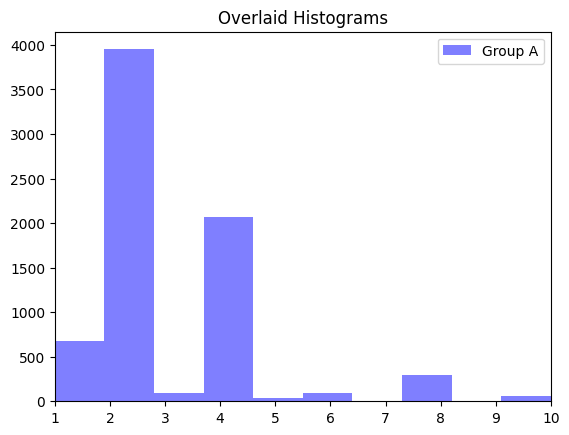

In [194]:
offlinemax_column = offlinemax_column[(1 <= offlinemax_column) & (offlinemax_column <= 10)]

plt.hist(offlinemax_column, alpha=0.5, label='Group A', color='blue')

plt.legend(loc='upper right')
plt.title('Overlaid Histograms')
plt.xlim(1,10)
plt.show()

None of these games actually support over 100 players; we need to drop these outliers.

### Online multiplayer

In [ ]:
onlinemax_column = modes_df['onlinemax'].sort_values(ascending = False)
outliers = onlinemax_column.iloc[:20]

In [169]:
max_games = modes_df.loc[outliers.index]
max_games

,id,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,platform,splitscreen
12461,22691,190890,False,False,False,0,0,False,0,5000,PC (Microsoft Windows),False
12078,22036,231860,False,False,False,0,0,False,0,5000,PC (Microsoft Windows),False
4938,11838,139279,False,False,False,0,0,False,0,5000,PC (Microsoft Windows),False
12077,22035,231860,False,False,False,0,0,False,0,5000,Web browser,False
14670,33323,337715,False,False,True,5,5,True,5,5000,PC (Microsoft Windows),False
23503,40345,396231,False,False,False,0,0,True,5000,5000,Web browser,False
20906,33902,342779,True,False,False,0,0,False,0,5000,Web browser,False
11251,20827,218762,False,False,False,0,0,True,5000,5000,PC (Microsoft Windows),False
9331,17984,188631,True,False,False,0,0,True,4000,4000,PC (Microsoft Windows),False
8587,16949,182119,False,False,False,0,0,False,0,4000,iOS,False


In [ ]:
max_games.merge(games_df, how = 'left', left_on = 'game', right_on = 'id')['name']

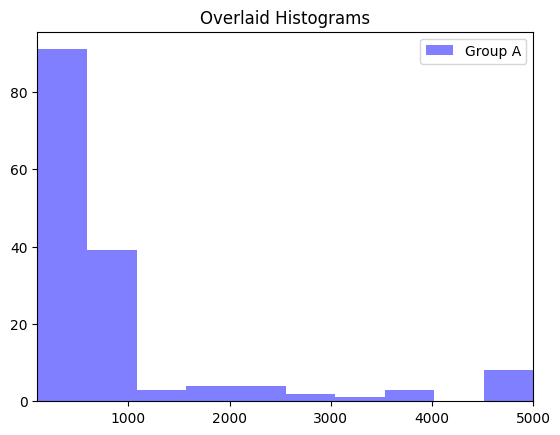

In [ ]:
onlinemax_column = onlinemax_column[(100 < onlinemax_column) & (onlinemax_column < 10000)]

plt.hist(onlinemax_column, alpha=0.5, label='Group A', color='blue')

plt.legend(loc='upper right')
plt.title('Overlaid Histograms')
plt.xlim(100, 5000)
plt.show()

After some testing, 5000 seems to be the sweet spot where obviously incorrect data is dropped, leaving only games with truly very high player counts (basically just MMOs)